# Phase 7 — 다중 객체 추적 (실무 방식 재구성)

정답지: `notebooks/06_multi_object_tracking.ipynb`, `src/perceptrack3d/tracking/{kalman_tracker.py, association.py}`, `docs/learning_notes/phase7_tracking.md`.

목표는 같다 — Phase 6 융합 결과(`outputs/phase6/objects_clustered.json`, 프레임마다 3D 중심 [x, y, z])를 **등속 칼만 필터 + 마할라노비스 게이트 + 헝가리안 할당 + 트랙 생명주기**로 이어 붙여 track_id 를 매기는 것.
차이는 만드는 방식이다. 정답지는 처음부터 설계해 썼고, 여기서는 실무자가 하듯 **검색해서 남의 코드를 가져다 붙인다**: 2D 추적의 표준 예제 SORT(2016)를 뼈대로, 3D 상태는 AB3DMOT(2020)에서, 칼만 필터 수식은 filterpy(라이브러리)에서, 할당은 scipy 문서 예제에서.

| 조각 | 출처 | 라이선스 | 왜 |
|---|---|---|---|
| 1. `KalmanBoxTracker` → 3D 중심 트랙 | SORT `sort.py` (abewley) + AB3DMOT `kalman_filter.py` (xinshuoweng) + filterpy 문서 | GPL-3.0 (SORT, 사용자 허락으로 원문 발췌) / MIT / MIT | 트랙 = "칼만 필터 하나 + 카운터" 라는 구조를 그대로 빌리고 상태만 [x,y,z,vx,vy,vz] 로 바꾼다 |
| 2. 칼만 `predict` / `update` 수식 | filterpy `kalman/kalman_filter.py` (rlabbe) | MIT | 직접 짜지 않고 라이브러리 수식을 읽는다. Joseph 형 P 갱신이 정답지와 어떻게 다른지 본다 |
| 3. 마할라노비스 거리 d² 와 혁신 공분산 S | AB3DMOT `compute_innovation_matrix` + filterpy `mahalanobis` 속성 | MIT | IoU 대신 쓸 비용. 게이트를 chi² 로 정한다 |
| 4. `associate_detections_to_trackers` + `linear_sum_assignment` | SORT `sort.py` + scipy 문서 예제 | GPL-3.0 / BSD-3 | 헝가리안 1:1 할당과 "게이트 밖 = inf" 처리 |
| 5. `Sort.update` 생명주기 (`max_age`, `min_hits`) | SORT `sort.py` | GPL-3.0 | 생성·확정·삭제 규칙. 우리 용어(max_misses, min_hits) 와 대응표 |

좌표계: 모든 3D 값은 **Velodyne** (x 전방, y 좌, z 상, m). 자차에 고정된 프레임이므로 추정 속도는 자차 기준 상대속도다.

In [1]:
import json, copy, collections, warnings
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from perceptrack3d.config import load_config
from perceptrack3d.fusion.frustum_fusion import load_objects_json   # 입력 데이터(융합 결과 JSON) 읽기 전용 — 지시서에서 허용

%matplotlib inline
plt.rcParams["figure.dpi"] = 100
np.random.seed(0)
rng = np.random.default_rng(0)
np.set_printoptions(precision=3, suppress=True, linewidth=140)

cfg = load_config()                                     # 경로·파라미터는 여기서만
OUT = Path(cfg["outputs"]["dir"])
tcfg = cfg["tracking"]
objects = load_objects_json(OUT / "phase6/objects_clustered.json")                     # {frame_id: [Object3D]}
tracks_ref = {int(k): v for k, v in json.load(open(OUT / "phase7/tracks.json")).items()}   # 정답지 결과 (이어붙이기에서 비교)
GT_XML = cfg["dataset"]["tracklets"]

def obs_of(frame_id):
    """그 프레임의 관측 = 융합이 성공(status ok)해 center (3,) 가 있는 Object3D 만."""
    return [o for o in objects[frame_id] if o.status == "ok" and o.center is not None]

n_ok = [len(obs_of(f)) for f in sorted(objects)]
print(f"프레임 {len(objects)}개, 관측(ok) 총 {sum(n_ok)}개 (프레임당 평균 {np.mean(n_ok):.2f}, 최대 {max(n_ok)})")
print("tracking 설정:", {k: tcfg[k] for k in ("dt", "gating", "gate_mahalanobis", "max_misses", "min_hits", "process_noise_pos", "process_noise_vel", "measurement_noise", "initial_vel_std")})
print("프레임 0 관측 예:", [f"{o.class_name} center={o.center} n_points={o.n_points}" for o in obs_of(0)[:2]])

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


프레임 297개, 관측(ok) 총 1107개 (프레임당 평균 3.73, 최대 8)
tracking 설정: {'dt': 0.1, 'gating': 'mahalanobis', 'gate_mahalanobis': 9.21, 'max_misses': 3, 'min_hits': 3, 'process_noise_pos': 0.5, 'process_noise_vel': 1.0, 'measurement_noise': 0.5, 'initial_vel_std': 10.0}
프레임 0 관측 예: ['car center=[46.9   21.835 -0.495] n_points=22', 'car center=[34.714  1.03  -0.572] n_points=34']


### 조각 1. SORT 의 `KalmanBoxTracker` 를 3D 중심 트랙으로 고쳐 쓰기

- **검색어**: `sort tracker kalman filter python github`, `ab3dmot kalman filter state vector`, `filterpy KalmanFilter example`
- **출처**:
  - SORT — https://github.com/abewley/sort (`sort.py`) — **GPL-3.0** (Copyright (C) 2016-2020 Alex Bewley. 사용자 허락으로 원문 발췌, 라이선스 표기 유지) — 2026-09-08 — `notebooks_2nd/sources/sort/sort.py`
  - AB3DMOT — https://github.com/xinshuoweng/AB3DMOT (`AB3DMOT_libs/kalman_filter.py`) — MIT — 2026-09-08 — `notebooks_2nd/sources/ab3dmot/kalman_filter.py`
  - filterpy 문서 — https://filterpy.readthedocs.io/en/latest/kalman/KalmanFilter.html — MIT — 2026-09-08. 설치: `.venv/bin/pip install --isolated --index-url https://pypi.org/simple filterpy` → 1.4.5
- **왜 이걸 가져오나**: 추적기의 뼈대("트랙 = 칼만 필터 하나 + hits/age/time_since_update 카운터")를 SORT 에서 그대로 빌린다. SORT 는 2D 박스 [u, v, s, r] 를 추적하므로 상태 정의만 AB3DMOT 의 3D 등속 모델을 참고해 [x, y, z, vx, vy, vz] 로 바꾼다.
- **읽을 때 볼 곳**: `sort.py` 의 `class KalmanBoxTracker` — `__init__` 에서 `KalmanFilter(dim_x=7, dim_z=4)` 와 `F`, `H`, 그리고 `R`, `P`, `Q` 를 곱셈으로 조정하는 5줄. `kalman_filter.py`(AB3DMOT) 의 `KF.__init__` — 10차원 상태 `x, y, z, theta, l, w, h, dx, dy, dz` 의 `F`(위치 ← 속도 결합) 와 `H`(앞 7개만 관측). 우리는 그중 위치 3 + 속도 3 만 남긴다.

filterpy 문서의 사용 예 (문서 URL 위, 원문):
```python
from filterpy.kalman import KalmanFilter
from filterpy.common import Q_discrete_white_noise
import numpy as np

f = KalmanFilter(dim_x=2, dim_z=1)

f.x = np.array([2., 0.])

f.F = np.array([[1.,1.],
                [0.,1.]])

f.H = np.array([[1.,0.]])

f.P *= 1000.

f.R = 5

f.Q = Q_discrete_white_noise(dim=2, dt=0.1, var=0.13)

while some_condition_is_true:
    z = get_sensor_reading()
    f.predict()
    f.update(z)
    do_something_with_estimate(f.x)
```

In [2]:
# ORIGINAL: sort/sort.py :: import + class KalmanBoxTracker (lines 30, 94-151), GPL-3.0 — Copyright (C) 2016-2020 Alex Bewley alex@bewley.ai
#           (GNU General Public License v3 — https://www.gnu.org/licenses/. 사용자 허락으로 학습용 원문 발췌)
import argparse

class KalmanBoxTracker(object):
  """
  This class represents the internal state of individual tracked objects observed as bbox.
  """
  count = 0
  def __init__(self,bbox):
    """
    Initialises a tracker using initial bounding box.
    """
    #define constant velocity model
    self.kf = KalmanFilter(dim_x=7, dim_z=4) 
    self.kf.F = np.array([[1,0,0,0,1,0,0],[0,1,0,0,0,1,0],[0,0,1,0,0,0,1],[0,0,0,1,0,0,0],  [0,0,0,0,1,0,0],[0,0,0,0,0,1,0],[0,0,0,0,0,0,1]])
    self.kf.H = np.array([[1,0,0,0,0,0,0],[0,1,0,0,0,0,0],[0,0,1,0,0,0,0],[0,0,0,1,0,0,0]])

    self.kf.R[2:,2:] *= 10.
    self.kf.P[4:,4:] *= 1000. #give high uncertainty to the unobservable initial velocities
    self.kf.P *= 10.
    self.kf.Q[-1,-1] *= 0.01
    self.kf.Q[4:,4:] *= 0.01

    self.kf.x[:4] = convert_bbox_to_z(bbox)
    self.time_since_update = 0
    self.id = KalmanBoxTracker.count
    KalmanBoxTracker.count += 1
    self.history = []
    self.hits = 0
    self.hit_streak = 0
    self.age = 0

  def update(self,bbox):
    """
    Updates the state vector with observed bbox.
    """
    self.time_since_update = 0
    self.history = []
    self.hits += 1
    self.hit_streak += 1
    self.kf.update(convert_bbox_to_z(bbox))

  def predict(self):
    """
    Advances the state vector and returns the predicted bounding box estimate.
    """
    if((self.kf.x[6]+self.kf.x[2])<=0):
      self.kf.x[6] *= 0.0
    self.kf.predict()
    self.age += 1
    if(self.time_since_update>0):
      self.hit_streak = 0
    self.time_since_update += 1
    self.history.append(convert_x_to_bbox(self.kf.x))
    return self.history[-1]

  def get_state(self):
    """
    Returns the current bounding box estimate.
    """
    return convert_x_to_bbox(self.kf.x)


# ORIGINAL: ab3dmot/kalman_filter.py :: class Filter, class KF.__init__ (lines 1-55), MIT — Copyright (c) 2019 Xinshuo Weng
import numpy as np
from filterpy.kalman import KalmanFilter, UnscentedKalmanFilter, MerweScaledSigmaPoints

class Filter(object):
	def __init__(self, bbox3D, info, ID):

		self.initial_pos = bbox3D
		self.time_since_update = 0
		self.id = ID
		self.hits = 1           		# number of total hits including the first detection
		self.info = info        		# other information associated	

class KF(Filter):
	def __init__(self, bbox3D, info, ID):
		super().__init__(bbox3D, info, ID)

		self.kf = KalmanFilter(dim_x=10, dim_z=7)       
		# There is no need to use EKF here as the measurement and state are in the same space with linear relationship

		# state x dimension 10: x, y, z, theta, l, w, h, dx, dy, dz
		# constant velocity model: x' = x + dx, y' = y + dy, z' = z + dz 
		# while all others (theta, l, w, h, dx, dy, dz) remain the same
		self.kf.F = np.array([[1,0,0,0,0,0,0,1,0,0],      # state transition matrix, dim_x * dim_x
		                      [0,1,0,0,0,0,0,0,1,0],
		                      [0,0,1,0,0,0,0,0,0,1],
		                      [0,0,0,1,0,0,0,0,0,0],  
		                      [0,0,0,0,1,0,0,0,0,0],
		                      [0,0,0,0,0,1,0,0,0,0],
		                      [0,0,0,0,0,0,1,0,0,0],
		                      [0,0,0,0,0,0,0,1,0,0],
		                      [0,0,0,0,0,0,0,0,1,0],
		                      [0,0,0,0,0,0,0,0,0,1]])     

		# measurement function, dim_z * dim_x, the first 7 dimensions of the measurement correspond to the state
		self.kf.H = np.array([[1,0,0,0,0,0,0,0,0,0],      
		                      [0,1,0,0,0,0,0,0,0,0],
		                      [0,0,1,0,0,0,0,0,0,0],
		                      [0,0,0,1,0,0,0,0,0,0],
		                      [0,0,0,0,1,0,0,0,0,0],
		                      [0,0,0,0,0,1,0,0,0,0],
		                      [0,0,0,0,0,0,1,0,0,0]])

		# measurement uncertainty, uncomment if not super trust the measurement data due to detection noise
		# self.kf.R[0:,0:] *= 10.   

		# initial state uncertainty at time 0
		# Given a single data, the initial velocity is very uncertain, so giv a high uncertainty to start
		self.kf.P[7:, 7:] *= 1000. 	
		self.kf.P *= 10.

		# process uncertainty, make the constant velocity part more certain
		self.kf.Q[7:, 7:] *= 0.01

		# initialize data
		self.kf.x[:7] = self.initial_pos.reshape((7, 1))
	# (이하 compute_innovation_matrix / get_velocity 는 조각 3 에서 발췌)
print('SORT KalmanBoxTracker 상태 차원:', 7, '(u, v, s, r, du, dv, ds)  /  AB3DMOT KF 상태 차원:', 10, '(x, y, z, θ, l, w, h, dx, dy, dz)')

SORT KalmanBoxTracker 상태 차원: 7 (u, v, s, r, du, dv, ds)  /  AB3DMOT KF 상태 차원: 10 (x, y, z, θ, l, w, h, dx, dy, dz)


In [3]:
# 우리 데이터에 적용: SORT KalmanBoxTracker 의 구조를 그대로 두고 상태만 3D 중심 [x, y, z, vx, vy, vz] 로 바꾼 트랙 클래스
from filterpy.kalman import KalmanFilter

class Track3D(object):
  """
  This class represents the internal state of individual tracked objects observed as bbox.
  """
  count = 0
  def __init__(self, center, dt, q_pos, q_vel, r_std, v0_std):     # CHANGED: bbox 대신 3D 중심 (3,) + 잡음 파라미터(configs/kitti.yaml tracking 절)
    """
    Initialises a tracker using initial bounding box.
    """
    #define constant velocity model
    self.kf = KalmanFilter(dim_x=6, dim_z=3)                          # CHANGED: dim_x 7→6, dim_z 4→3 (2D 박스 [u,v,s,r] → 3D 중심 [x,y,z])
    I3, Z3 = np.eye(3), np.zeros((3, 3))
    self.kf.F = np.block([[I3, dt * I3], [Z3, I3]])                   # CHANGED: AB3DMOT 의 "x' = x + dx" 를 dt 가 붙은 형태로. SORT/AB3DMOT 는 dt=1 프레임, 우리는 dt=0.1 s (KITTI 10 Hz)
    self.kf.H = np.hstack([I3, Z3])                                   # CHANGED: 위치 3개만 관측 (3×6). 속도는 관측하지 않는다
    self.kf.R = (r_std ** 2) * I3                                     # CHANGED: SORT 의 "R[2:,2:] *= 10." 대신 융합 중심 오차 σ (measurement_noise, m) 로 직접
    self.kf.P = np.diag([r_std ** 2] * 3 + [v0_std ** 2] * 3)         # CHANGED: SORT 의 "P[4:,4:] *= 1000.; P *= 10." 과 같은 뜻 — 첫 관측에서 속도는 모른다 (initial_vel_std)
    self.kf.Q = np.diag([q_pos ** 2] * 3 + [q_vel ** 2] * 3)          # CHANGED: SORT 의 "Q[-1,-1] *= 0.01; Q[4:,4:] *= 0.01" 대신 위치/속도 σ 로 (process_noise_pos/vel)
    self.kf.x = np.concatenate([np.asarray(center, dtype=float), np.zeros(3)])   # CHANGED: x[:4] = convert_bbox_to_z(bbox) → 위치 = 관측, 속도 = 0
    self.time_since_update = 0
    self.id = Track3D.count
    Track3D.count += 1
    self.history = []
    self.hits = 1                                                     # CHANGED: SORT 는 0. 우리는 첫 관측도 hit 로 센다 (정답지 규약: hits >= min_hits 로 확정)
    self.hit_streak = 0
    self.age = 0
    self.confirmed = False                                            # CHANGED: 한 번 확정되면 유지하기 위한 플래그 (조각 5)
    self.size, self.class_name = None, ""                             # CHANGED: 마지막 관측 크기/클래스 (출력용, 필터는 위치만 추정)

  def update(self, center):                                           # CHANGED: bbox → center (3,)
    """
    Updates the state vector with observed bbox.
    """
    self.time_since_update = 0
    self.history = []
    self.hits += 1
    self.hit_streak += 1
    self.kf.update(np.asarray(center, dtype=float))                   # CHANGED: convert_bbox_to_z(bbox) 없이 관측을 그대로

  def predict(self):
    """
    Advances the state vector and returns the predicted bounding box estimate.
    """
    # CHANGED: SORT 의 "if((self.kf.x[6]+self.kf.x[2])<=0): self.kf.x[6] *= 0.0" (면적이 음수가 되는 것 방지) 는 3D 중심에 해당 없음 → 삭제
    self.kf.predict()
    self.age += 1
    if(self.time_since_update>0):
      self.hit_streak = 0
    self.time_since_update += 1
    self.history.append(self.kf.x[:3].copy())                        # CHANGED: convert_x_to_bbox(self.kf.x) → 위치 3개
    return self.history[-1]

  def get_state(self):
    """
    Returns the current bounding box estimate.
    """
    return self.kf.x[:3]                                              # CHANGED: convert_x_to_bbox → 위치 3개

  def as_dict(self, frame_id):                                        # CHANGED: 정답지 tracks.json 한 줄과 같은 형식으로 내보내기 (이어붙이기에서 비교)
    return {"frame_id": int(frame_id), "track_id": self.id + 1, "class_name": self.class_name,     # +1: SORT 도 출력 때 id+1 ("MOT benchmark requires positive")
            "center": [float(v) for v in self.kf.x[:3]], "velocity": [float(v) for v in self.kf.x[3:]],
            "size": None if self.size is None else [float(v) for v in self.size],
            "hits": self.hits, "age": self.age, "misses": self.time_since_update, "confirmed": self.confirmed}

KF_ARGS = (tcfg["dt"], tcfg["process_noise_pos"], tcfg["process_noise_vel"], tcfg["measurement_noise"], tcfg["initial_vel_std"])
Track3D.count = 0
z0 = obs_of(0)[1].center                       # 프레임 0 의 두 번째 관측 (자차 앞 같은 차선의 차, x≈35 m) — 정답지 노트북 06 §6.1 과 같은 예
trk = Track3D(z0, *KF_ARGS)
print("F (6,6) =\n", trk.kf.F, "\nH (3,6) =\n", trk.kf.H)
print("Q diag =", np.diag(trk.kf.Q), "  R diag =", np.diag(trk.kf.R))
print(f"z0 = {z0}  →  x0 = {trk.kf.x}  (shape {trk.kf.x.shape}, dtype {trk.kf.x.dtype})")
print("P0 diag =", np.diag(trk.kf.P), " (위치 σ² = R, 속도 σ² = initial_vel_std²)")

F (6,6) =
 [[1.  0.  0.  0.1 0.  0. ]
 [0.  1.  0.  0.  0.1 0. ]
 [0.  0.  1.  0.  0.  0.1]
 [0.  0.  0.  1.  0.  0. ]
 [0.  0.  0.  0.  1.  0. ]
 [0.  0.  0.  0.  0.  1. ]] 
H (3,6) =
 [[1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]]
Q diag = [0.25 0.25 0.25 1.   1.   1.  ]   R diag = [0.25 0.25 0.25]
z0 = [34.714  1.03  -0.572]  →  x0 = [34.714  1.03  -0.572  0.     0.     0.   ]  (shape (6,), dtype float64)
P0 diag = [  0.25   0.25   0.25 100.   100.   100.  ]  (위치 σ² = R, 속도 σ² = initial_vel_std²)


In [4]:
# 검증: 정답지 KalmanFilterCV 와 행렬·초기 상태가 같은가
from perceptrack3d.tracking.kalman_tracker import KalmanFilterCV

kf_ref = KalmanFilterCV(*KF_ARGS)
x_ref, P_ref = kf_ref.init_state(z0)
checks = {"F": np.allclose(trk.kf.F, kf_ref.F), "H": np.allclose(trk.kf.H, kf_ref.H), "Q": np.allclose(trk.kf.Q, kf_ref.Q),
          "R": np.allclose(trk.kf.R, kf_ref.R), "x0": np.allclose(trk.kf.x, x_ref), "P0": np.allclose(trk.kf.P, P_ref)}
print("정답지 KalmanFilterCV 와 비교:", checks)
assert all(checks.values())
print("→ SORT 의 'P *= 10, Q *= 0.01' 식 스케일링을 σ 파라미터로 바꿔 쓴 것뿐, 모델은 동일")

정답지 KalmanFilterCV 와 비교: {'F': True, 'H': True, 'Q': True, 'R': True, 'x0': True, 'P0': True}
→ SORT 의 'P *= 10, Q *= 0.01' 식 스케일링을 σ 파라미터로 바꿔 쓴 것뿐, 모델은 동일


### 조각 2. filterpy 의 `predict` / `update` 수식 읽기 — 정지 물체 10 관측으로 수렴 확인

- **검색어**: `filterpy kalman predict update source`, `kalman filter joseph form covariance update`
- **출처**: filterpy — https://github.com/rlabbe/filterpy (`filterpy/kalman/kalman_filter.py`) — MIT (Copyright 2014-2018 Roger R Labbe Jr.) — 2026-09-08 — `notebooks_2nd/sources/filterpy/kalman_filter.py`. 문서: https://filterpy.readthedocs.io/en/latest/kalman/KalmanFilter.html
- **왜 이걸 가져오나**: 조각 1 의 `Track3D` 가 안에서 부르는 `kf.predict()` / `kf.update(z)` 가 정확히 어떤 식인지 확인해야 정답지(`KalmanFilterCV.predict/update`) 와 같은 결과가 나오는지 판단할 수 있다. filterpy 에는 같은 수식이 **절차형 함수** `predict(x, P, F, Q)`, `update(x, P, z, R, H)` 로도 있어 (x, P) 를 직접 넣어 볼 수 있다.
- **읽을 때 볼 곳**: 모듈 독스트링 "All Kalman filters operate with a predict->update cycle ..." 절. 절차형 `predict()` 의 `x = dot(F, x) + dot(B, u)`, `P = (alpha * alpha) * dot(dot(F, P), F.T) + Q`. `update()` 의 `y = z - Hx`, `S = HPH' + R`, `K = PH' inv(S)`, `x = x + Ky`, 그리고 **`P = (I-KH)P(I-KH)' + KRK'`** 주석 — "This is more numerically stable ... vs the equation P = (I-KH)P usually seen in the literature" (Joseph 형). 정답지는 문헌형 `(I − KH)P` 를 쓴다.

```
예측  x⁻ = F x            P⁻ = F P Fᵀ + Q
갱신  y  = z − H x⁻       S = H P⁻ Hᵀ + R       K = P⁻ Hᵀ S⁻¹
      x  = x⁻ + K y       P = (I − KH) P⁻ (I − KH)ᵀ + K R Kᵀ     ← filterpy (Joseph 형; K 가 최적이면 (I − KH)P⁻ 와 같다)
```

In [5]:
# ORIGINAL: filterpy/kalman_filter.py :: imports (lines 126-131), 절차형 predict() (lines 1571-1621), update() (lines 1401-1508), MIT — Copyright 2014-2018 Roger R Labbe Jr.
import numpy as np
from numpy import dot, zeros, eye, isscalar, shape
import numpy.linalg as linalg
from filterpy.stats import logpdf
from filterpy.common import pretty_str, reshape_z



def predict(x, P, F=1, Q=0, u=0, B=1, alpha=1.):
    """
    Predict next state (prior) using the Kalman filter state propagation
    equations.

    Parameters
    ----------

    x : numpy.array
        State estimate vector

    P : numpy.array
        Covariance matrix

    F : numpy.array()
        State Transition matrix

    Q : numpy.array, Optional
        Process noise matrix


    u : numpy.array, Optional, default 0.
        Control vector. If non-zero, it is multiplied by B
        to create the control input into the system.

    B : numpy.array, optional, default 0.
        Control transition matrix.

    alpha : float, Optional, default=1.0
        Fading memory setting. 1.0 gives the normal Kalman filter, and
        values slightly larger than 1.0 (such as 1.02) give a fading
        memory effect - previous measurements have less influence on the
        filter's estimates. This formulation of the Fading memory filter
        (there are many) is due to Dan Simon

    Returns
    -------

    x : numpy.array
        Prior state estimate vector

    P : numpy.array
        Prior covariance matrix
    """

    if np.isscalar(F):
        F = np.array(F)
    x = dot(F, x) + dot(B, u)
    P = (alpha * alpha) * dot(dot(F, P), F.T) + Q

    return x, P


def update(x, P, z, R, H=None, return_all=False):
    """
    Add a new measurement (z) to the Kalman filter. If z is None, nothing
    is changed.

    This can handle either the multidimensional or unidimensional case. If
    all parameters are floats instead of arrays the filter will still work,
    and return floats for x, P as the result.

    update(1, 2, 1, 1, 1)  # univariate
    update(x, P, 1



    Parameters
    ----------

    x : numpy.array(dim_x, 1), or float
        State estimate vector

    P : numpy.array(dim_x, dim_x), or float
        Covariance matrix

    z : (dim_z, 1): array_like
        measurement for this update. z can be a scalar if dim_z is 1,
        otherwise it must be convertible to a column vector.

    R : numpy.array(dim_z, dim_z), or float
        Measurement noise matrix

    H : numpy.array(dim_x, dim_x), or float, optional
        Measurement function. If not provided, a value of 1 is assumed.

    return_all : bool, default False
        If true, y, K, S, and log_likelihood are returned, otherwise
        only x and P are returned.

    Returns
    -------

    x : numpy.array
        Posterior state estimate vector

    P : numpy.array
        Posterior covariance matrix

    y : numpy.array or scalar
        Residua. Difference between measurement and state in measurement space

    K : numpy.array
        Kalman gain

    S : numpy.array
        System uncertainty in measurement space

    log_likelihood : float
        log likelihood of the measurement
    """

    #pylint: disable=bare-except

    if z is None:
        if return_all:
            return x, P, None, None, None, None
        return x, P

    if H is None:
        H = np.array([1])

    if np.isscalar(H):
        H = np.array([H])

    Hx = np.atleast_1d(dot(H, x))
    z = reshape_z(z, Hx.shape[0], x.ndim)

    # error (residual) between measurement and prediction
    y = z - Hx

    # project system uncertainty into measurement space
    S = dot(dot(H, P), H.T) + R


    # map system uncertainty into kalman gain
    try:
        K = dot(dot(P, H.T), linalg.inv(S))
    except:
        # can't invert a 1D array, annoyingly
        K = dot(dot(P, H.T), 1./S)


    # predict new x with residual scaled by the kalman gain
    x = x + dot(K, y)

    # P = (I-KH)P(I-KH)' + KRK'
    KH = dot(K, H)

    try:
        I_KH = np.eye(KH.shape[0]) - KH
    except:
        I_KH = np.array([1 - KH])
    P = dot(dot(I_KH, P), I_KH.T) + dot(dot(K, R), K.T)


    if return_all:
        # compute log likelihood
        log_likelihood = logpdf(z, dot(H, x), S)
        return x, P, y, K, S, log_likelihood
    return x, P

print('절차형 predict/update 정의됨 (filterpy 원문). 조각 1 의 Track3D 는 같은 수식의 객체형 KalmanFilter.predict/update 를 부른다')

절차형 predict/update 정의됨 (filterpy 원문). 조각 1 의 Track3D 는 같은 수식의 객체형 KalmanFilter.predict/update 를 부른다


객체형(KalmanFilter) == 절차형(predict/update): True
 k                   x̂ (m) v̂x (m/s)  P00 var(x) m²  P33 var(vx) |x̂ − c_true| m
 0   [30.038  4.96  -0.308]     0.000         0.2500      100.000           0.200
 1   [30.032  4.857 -0.38 ]    -0.036         0.2143       43.857           0.190
 2   [30.328  5.198 -0.662]     1.429         0.2066       21.357           0.416
 3   [29.81   4.928 -0.563]    -0.956         0.1943       13.537           0.213
 4   [29.409  4.929 -0.811]    -1.828         0.1856       10.184           0.672
 5   [29.625  4.86  -0.689]    -0.868         0.1800        8.502           0.442
 6   [29.952  5.173 -0.601]     0.014         0.1766        7.568           0.206
 7   [30.272  4.928 -0.466]     0.640         0.1745        7.015           0.284
 8   [30.291  4.994 -0.643]     0.556         0.1731        6.675           0.324
 9   [29.917  4.905 -0.508]    -0.210         0.1723        6.460           0.126


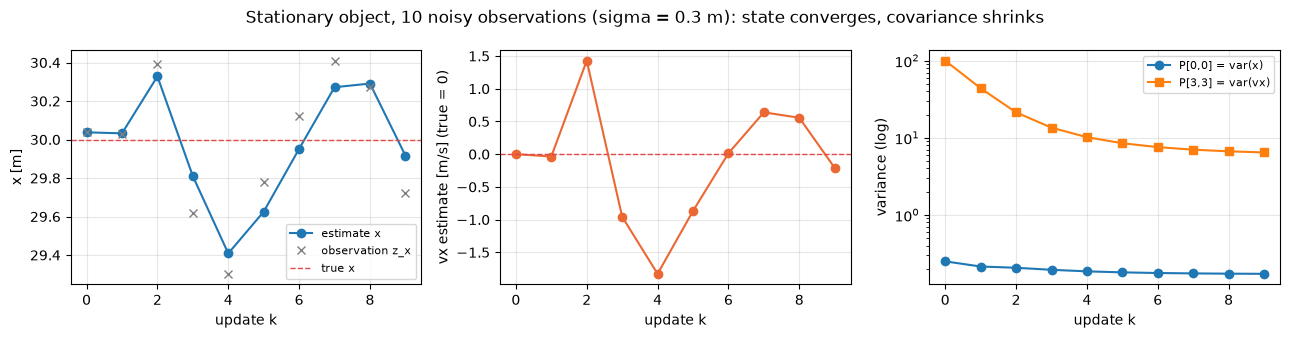

In [6]:
# 우리 데이터에 적용: 정지한 물체(진짜 중심 c_true) 를 σ=0.3 m 잡음으로 10번 관측 → 상태 수렴, 공분산 감소
c_true = np.array([30.0, 5.0, -0.5])                 # Velodyne (m): 30 m 앞, 5 m 왼쪽
zs = c_true + rng.normal(0.0, 0.3, size=(10, 3))     # 합성 관측 10개 (시드 고정)

# (a) 객체형: 조각 1 Track3D 그대로 (안에서 filterpy KalmanFilter.predict/update)
Track3D.count = 0
t = Track3D(zs[0], *KF_ARGS)
hist_oo = [(t.kf.x.copy(), t.kf.P.copy())]
for z in zs[1:]:
    t.predict(); t.update(z)
    hist_oo.append((t.kf.x.copy(), t.kf.P.copy()))

# (b) 절차형: 위 원문 predict()/update() 에 (x, P) 를 직접 넣어 같은 값이 나오는지
x, P = np.concatenate([zs[0], np.zeros(3)]), np.diag([tcfg["measurement_noise"] ** 2] * 3 + [tcfg["initial_vel_std"] ** 2] * 3)
hist_fn = [(x.copy(), P.copy())]
for z in zs[1:]:
    x, P = predict(x, P, F=t.kf.F, Q=t.kf.Q)         # 원문 절차형 predict
    x, P = update(x, P, z, R=t.kf.R, H=t.kf.H)       # 원문 절차형 update
    hist_fn.append((x.copy(), P.copy()))
print("객체형(KalmanFilter) == 절차형(predict/update):", all(np.allclose(a[0], b[0]) and np.allclose(a[1], b[1]) for a, b in zip(hist_oo, hist_fn)))

print(f"{'k':>2} {'x̂ (m)':>24} {'v̂x (m/s)':>9} {'P00 var(x) m²':>14} {'P33 var(vx)':>12} {'|x̂ − c_true| m':>15}")
for k, (xk, Pk) in enumerate(hist_oo):
    print(f"{k:>2} {str(xk[:3]):>24} {xk[3]:9.3f} {Pk[0, 0]:14.4f} {Pk[3, 3]:12.3f} {np.linalg.norm(xk[:3] - c_true):15.3f}")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
ks = np.arange(len(hist_oo))
axes[0].plot(ks, [h[0][0] for h in hist_oo], "o-", label="estimate x")
axes[0].plot(ks, zs[:, 0], "x", color="0.5", label="observation z_x"); axes[0].axhline(c_true[0], color="#e34948", ls="--", lw=1, label="true x")
axes[0].set_xlabel("update k"); axes[0].set_ylabel("x [m]"); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
axes[1].plot(ks, [h[0][3] for h in hist_oo], "o-", color="#eb6834"); axes[1].axhline(0, color="#e34948", ls="--", lw=1)
axes[1].set_xlabel("update k"); axes[1].set_ylabel("vx estimate [m/s] (true = 0)"); axes[1].grid(alpha=0.3)
axes[2].semilogy(ks, [h[1][0, 0] for h in hist_oo], "o-", label="P[0,0] = var(x)")
axes[2].semilogy(ks, [h[1][3, 3] for h in hist_oo], "s-", label="P[3,3] = var(vx)")
axes[2].set_xlabel("update k"); axes[2].set_ylabel("variance (log)"); axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)
fig.suptitle("Stationary object, 10 noisy observations (sigma = 0.3 m): state converges, covariance shrinks"); fig.tight_layout(); plt.show()

In [7]:
# 검증: 정답지 KalmanFilterCV.predict/update 에 같은 입력 → 상태·공분산 allclose (Joseph 형 vs (I−KH)P 차이는 부동소수점 수준이어야 한다)
kf_ref = KalmanFilterCV(*KF_ARGS)
x_r, P_r = kf_ref.init_state(zs[0])
max_dx = max_dP = 0.0
for k, z in enumerate(zs[1:], start=1):
    x_r, P_r = kf_ref.predict(x_r, P_r)
    x_r, P_r = kf_ref.update(x_r, P_r, z)
    max_dx = max(max_dx, np.abs(x_r - hist_oo[k][0]).max()); max_dP = max(max_dP, np.abs(P_r - hist_oo[k][1]).max())
print(f"10 스텝 동안 정답지와 최대 차이: 상태 {max_dx:.2e}, 공분산 {max_dP:.2e}")
assert max_dx < 1e-9 and max_dP < 1e-9
print("→ filterpy 의 Joseph 형 P = (I−KH)P(I−KH)ᵀ + KRKᵀ 와 정답지의 P = (I−KH)P 는 K 가 최적 이득일 때 수학적으로 같다. 차이는 수치 오차뿐")

10 스텝 동안 정답지와 최대 차이: 상태 3.66e-15, 공분산 1.42e-14
→ filterpy 의 Joseph 형 P = (I−KH)P(I−KH)ᵀ + KRKᵀ 와 정답지의 P = (I−KH)P 는 K 가 최적 이득일 때 수학적으로 같다. 차이는 수치 오차뿐


### 조각 3. 마할라노비스 거리 d² 와 혁신 공분산 S — IoU 대신 쓸 비용

- **검색어**: `ab3dmot mahalanobis distance association`, `filterpy mahalanobis`, `chi square gate 3 dof 0.975`
- **출처**: AB3DMOT `kalman_filter.py` 의 `compute_innovation_matrix` — MIT — 2026-09-08 — `notebooks_2nd/sources/ab3dmot/kalman_filter.py`. filterpy `kalman_filter.py` 의 `KalmanFilter.mahalanobis` 속성 — MIT — `notebooks_2nd/sources/filterpy/kalman_filter.py`. 게이트 임계값은 scipy `scipy.stats.chi2` 로 계산 (https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2.html, BSD-3).
- **왜 이걸 가져오나**: SORT 는 2D 박스 IoU 로 트랙–검출을 잇지만 우리 관측은 3D 점이라 IoU 가 없다. AB3DMOT 가 3D 에서 쓰는 **혁신 공분산 S = H P Hᵀ + R** 로 정규화한 거리 d² = yᵀ S⁻¹ y 를 비용으로 쓴다. 불확실한(오래 못 본) 트랙일수록 S 가 커서 같은 m 오차라도 d² 가 작다 → 게이트가 자동으로 넓어진다.
- **읽을 때 볼 곳**: `compute_innovation_matrix` 의 한 줄 `H P Hᵀ + R` ("for association with mahalanobis distance"). filterpy `mahalanobis` 의 `sqrt(y.T · SI · y)` — 즉 d² = yᵀ S⁻¹ y (SI = S⁻¹). 모델이 맞으면 d² ~ chi²(자유도 = 관측 차원 3).

```
y  = z − H x⁻                 (3,)   혁신(innovation): 예측 위치와 관측의 차이
S  = H P⁻ Hᵀ + R              (3,3)  혁신 공분산: 예측 불확실성 + 관측 잡음
d² = yᵀ S⁻¹ y                 스칼라, chi²(3) 분포 → 게이트 9.21 ≈ p 0.973
```

In [8]:
# ORIGINAL: ab3dmot/kalman_filter.py :: KF.compute_innovation_matrix (lines 57-60), MIT — Copyright (c) 2019 Xinshuo Weng
class KF(Filter):   # 원문 클래스 껍데기 (메서드만 발췌했으므로 들여쓰기를 살리기 위해 추가)
	def compute_innovation_matrix(self):
		""" compute the innovation matrix for association with mahalanobis distance
		"""
		return np.matmul(np.matmul(self.kf.H, self.kf.P), self.kf.H.T) + self.kf.R


# ORIGINAL: filterpy/kalman_filter.py :: KalmanFilter.mahalanobis 속성 (lines 1227-1239), MIT — Copyright 2014-2018 Roger R Labbe Jr.
class _filterpy_KalmanFilter(object):   # 원문 class KalmanFilter 의 껍데기 (조각 1 에서 import 한 filterpy KalmanFilter 와 이름 충돌을 피함)
    @property
    def mahalanobis(self):
        """"
        Mahalanobis distance of measurement. E.g. 3 means measurement
        was 3 standard deviations away from the predicted value.

        Returns
        -------
        mahalanobis : float
        """
        if self._mahalanobis is None:
            self._mahalanobis = sqrt(float(dot(dot(self.y.T, self.SI), self.y)))
        return self._mahalanobis

print('S = H P Hᵀ + R  /  d = sqrt(yᵀ S⁻¹ y)  — 두 원문 모두 같은 수식. 우리는 sqrt 없이 d² 를 비용으로 쓴다')

S = H P Hᵀ + R  /  d = sqrt(yᵀ S⁻¹ y)  — 두 원문 모두 같은 수식. 우리는 sqrt 없이 d² 를 비용으로 쓴다


프레임 0 트랙 3개 (예측 후 P[0,0] = 1.500 m², S 대각 = [1.75 1.75 1.75]) × 프레임 1 관측 5개
d² 행렬 (행 = 관측, 열 = 트랙):
 [[  1.99  306.54   97.487]
 [333.991   0.019 570.602]
 [ 49.781 516.443   1.987]
 [ 37.834 523.722   7.46 ]
 [296.995 975.447  77.047]]
유클리드 거리 (m):
 [[ 1.866 23.161 13.061]
 [24.176  0.184 31.6  ]
 [ 9.334 30.063  1.865]
 [ 8.137 30.274  3.613]
 [22.798 41.316 11.612]]
게이트 9.21: chi²(3 자유도) 누적확률 = 0.9734  (p=0.975 분위수는 9.35). 게이트 안 쌍 수 = 4 / 15


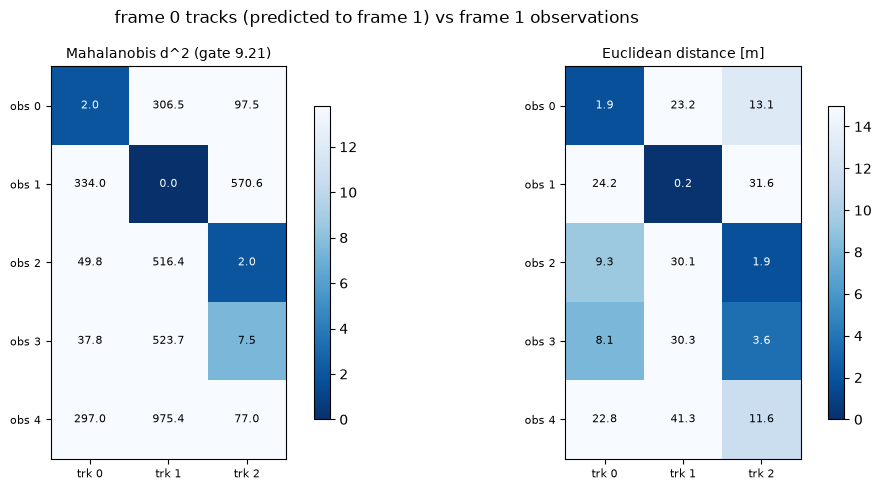

In [9]:
# 우리 데이터에 적용: 프레임 0 관측으로 트랙을 만들고 한 프레임 예측 → 프레임 1 관측과의 d² 행렬 (D, T) 와 유클리드 거리 (m) 비교
from scipy.stats import chi2

def mahalanobis_matrix(dets, trackers):
    """dets (D,3) 관측 × trackers (예측 완료된 Track3D) → d² 행렬 (D, T). SORT 의 iou_batch 처럼 행 = 검출, 열 = 트랙."""
    dets = np.asarray(dets, dtype=float).reshape(-1, 3)
    D2 = np.zeros((len(dets), len(trackers)))
    for j, trk in enumerate(trackers):
        H, P, R, x = trk.kf.H, trk.kf.P, trk.kf.R, trk.kf.x
        S = np.matmul(np.matmul(H, P), H.T) + R                  # PORTED FROM AB3DMOT compute_innovation_matrix
        S_inv = np.linalg.inv(S)
        Y = dets - H @ x                                          # (D,3) 혁신 y = z − H x⁻ (관측마다)
        D2[:, j] = np.einsum("dj,jk,dk->d", Y, S_inv, Y)          # d² = yᵀ S⁻¹ y  (filterpy mahalanobis 의 sqrt 안쪽)
    return D2

Track3D.count = 0
trackers = [Track3D(o.center, *KF_ARGS) for o in obs_of(0)]       # 프레임 0 관측 → 트랙 (SORT 처럼 미매칭 검출은 곧 새 트랙)
for trk in trackers:
    trk.predict()                                                  # 프레임 1 로 예측: P 가 커진다 (특히 속도 불확실성 initial_vel_std 가 위치로 번짐)
dets1 = np.array([o.center for o in obs_of(1)])
D2 = mahalanobis_matrix(dets1, trackers)
EU = np.linalg.norm(dets1[:, None, :] - np.array([t.kf.x[:3] for t in trackers])[None, :, :], axis=2)
GATE = tcfg["gate_mahalanobis"]
print(f"프레임 0 트랙 {len(trackers)}개 (예측 후 P[0,0] = {trackers[0].kf.P[0, 0]:.3f} m², S 대각 = {np.diag(trackers[0].kf.H @ trackers[0].kf.P @ trackers[0].kf.H.T + trackers[0].kf.R)}) × 프레임 1 관측 {len(dets1)}개")
print("d² 행렬 (행 = 관측, 열 = 트랙):\n", D2)
print("유클리드 거리 (m):\n", EU)
print(f"게이트 {GATE}: chi²(3 자유도) 누적확률 = {chi2.cdf(GATE, 3):.4f}  (p=0.975 분위수는 {chi2.ppf(0.975, 3):.2f}). 게이트 안 쌍 수 = {(D2 <= GATE).sum()} / {D2.size}")

fig, axes = plt.subplots(1, 2, figsize=(11, 0.55 * len(dets1) + 2.2))
for ax, M, title, vmax in [(axes[0], D2, f"Mahalanobis d^2 (gate {GATE})", GATE), (axes[1], EU, "Euclidean distance [m]", 10)]:
    im = ax.imshow(np.minimum(M, vmax * 1.5), cmap="Blues_r", vmin=0, vmax=vmax * 1.5)
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            ax.text(j, i, f"{M[i, j]:.1f}", ha="center", va="center", fontsize=8, color="white" if M[i, j] < vmax * 0.75 else "black")
    ax.set_xticks(range(len(trackers)), [f"trk {t.id}" for t in trackers], fontsize=8); ax.set_yticks(range(len(dets1)), [f"obs {i}" for i in range(len(dets1))], fontsize=8)
    ax.set_title(title, fontsize=10); fig.colorbar(im, ax=ax, shrink=0.8)
fig.suptitle("frame 0 tracks (predicted to frame 1) vs frame 1 observations"); fig.tight_layout(); plt.show()

In [10]:
# 검증: 정답지 build_cost_matrix(gating='mahalanobis') 와 같은 값인가 (정답지는 행 = 트랙, 열 = 관측 → 전치해서 비교. 게이트 밖은 inf)
from perceptrack3d.tracking.association import build_cost_matrix
from perceptrack3d.types import Track

tracks_ref_objs = [Track(track_id=t.id + 1, class_name="", state=t.kf.x.copy(), covariance=t.kf.P.copy()) for t in trackers]
cost_ref = build_cost_matrix(tracks_ref_objs, obs_of(1), gating="mahalanobis", gate_mahalanobis=GATE, R=trackers[0].kf.R)
mine = np.where(D2.T <= GATE, D2.T, np.inf)
same_pattern = np.array_equal(np.isfinite(mine), np.isfinite(cost_ref))
same_values = np.allclose(mine[np.isfinite(mine)], cost_ref[np.isfinite(cost_ref)])
print(f"정답지 cost (T,D) shape {cost_ref.shape} vs 우리 D2.T {mine.shape}: inf 패턴 동일 {same_pattern}, 유한값 allclose {same_values}")
assert same_pattern and same_values
print("→ 같은 S, 같은 d². 차이는 행/열 규약뿐 (SORT 는 행 = 검출, 정답지는 행 = 트랙)")

정답지 cost (T,D) shape (3, 5) vs 우리 D2.T (3, 5): inf 패턴 동일 True, 유한값 allclose True
→ 같은 S, 같은 d². 차이는 행/열 규약뿐 (SORT 는 행 = 검출, 정답지는 행 = 트랙)


### 조각 4. SORT 의 `associate_detections_to_trackers` + scipy `linear_sum_assignment` — IoU 를 d² 로 바꾸기

- **검색어**: `hungarian algorithm python scipy linear_sum_assignment`, `sort associate_detections_to_trackers`
- **출처**: SORT `sort.py` 의 `linear_assignment`, `associate_detections_to_trackers` — **GPL-3.0** (Alex Bewley, 사용자 허락으로 원문 발췌) — 2026-09-08. scipy 문서 — https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.linear_sum_assignment.html — BSD-3 — 2026-09-08 (scipy 1.18.1 설치됨).
- **왜 이걸 가져오나**: 트랙 T개 × 관측 D개 비용 행렬에서 총비용 최소 **일대일** 할당(헝가리안)을 직접 짜지 않는다. SORT 는 `lap` 이 있으면 `lapjv`, 없으면 scipy `linear_sum_assignment` 로 폴백한다 — 우리는 scipy 만 쓴다.
- **읽을 때 볼 곳**: `associate_detections_to_trackers` — (1) `iou_matrix > iou_threshold` 가 행·열마다 정확히 하나면 헝가리안 없이 바로 매칭, 아니면 `linear_assignment(-iou_matrix)` (IoU 는 **최대화** 라 부호를 뒤집음), (2) 할당 결과 중 `iou < threshold` 인 쌍은 사후에 버림. scipy 문서 예제: `cost = [[4,1,3],[2,0,5],[3,2,2]]` → `col_ind = [1, 0, 2]`, 총비용 5.

scipy 문서 Examples 절 (원문):
```python
>>> import numpy as np
>>> cost = np.array([[4, 1, 3], [2, 0, 5], [3, 2, 2]])
>>> from scipy.optimize import linear_sum_assignment
>>> row_ind, col_ind = linear_sum_assignment(cost)
>>> col_ind
array([1, 0, 2])
>>> cost[row_ind, col_ind].sum()
5
```

**inf 처리**: 게이트 밖 쌍을 `np.inf` 로 두면 scipy 는 완전한 할당이 불가능할 때(예: 한 행이 전부 inf) `ValueError: cost matrix is infeasible` 를 낸다. 실무 해법은 inf 를 "어떤 유한 비용의 합보다 큰 유한값" 으로 바꿔 풀고, 결과에서 원래 inf 였던 쌍을 버리는 것 — 아래 B 셀에서 직접 확인한다.

In [11]:
# ORIGINAL: sort/sort.py :: linear_assignment (lines 36-44), associate_detections_to_trackers (lines 154-197), GPL-3.0 — Copyright (C) 2016-2020 Alex Bewley
def linear_assignment(cost_matrix):
  try:
    import lap
    _, x, y = lap.lapjv(cost_matrix, extend_cost=True)
    return np.array([[y[i],i] for i in x if i >= 0]) #
  except ImportError:
    from scipy.optimize import linear_sum_assignment
    x, y = linear_sum_assignment(cost_matrix)
    return np.array(list(zip(x, y)))


def associate_detections_to_trackers(detections,trackers,iou_threshold = 0.3):
  """
  Assigns detections to tracked object (both represented as bounding boxes)

  Returns 3 lists of matches, unmatched_detections and unmatched_trackers
  """
  if(len(trackers)==0):
    return np.empty((0,2),dtype=int), np.arange(len(detections)), np.empty((0,5),dtype=int)

  iou_matrix = iou_batch(detections, trackers)

  if min(iou_matrix.shape) > 0:
    a = (iou_matrix > iou_threshold).astype(np.int32)
    if a.sum(1).max() == 1 and a.sum(0).max() == 1:
        matched_indices = np.stack(np.where(a), axis=1)
    else:
      matched_indices = linear_assignment(-iou_matrix)
  else:
    matched_indices = np.empty(shape=(0,2))

  unmatched_detections = []
  for d, det in enumerate(detections):
    if(d not in matched_indices[:,0]):
      unmatched_detections.append(d)
  unmatched_trackers = []
  for t, trk in enumerate(trackers):
    if(t not in matched_indices[:,1]):
      unmatched_trackers.append(t)

  #filter out matched with low IOU
  matches = []
  for m in matched_indices:
    if(iou_matrix[m[0], m[1]]<iou_threshold):
      unmatched_detections.append(m[0])
      unmatched_trackers.append(m[1])
    else:
      matches.append(m.reshape(1,2))
  if(len(matches)==0):
    matches = np.empty((0,2),dtype=int)
  else:
    matches = np.concatenate(matches,axis=0)

  return matches, np.array(unmatched_detections), np.array(unmatched_trackers)



# ORIGINAL: scipy 문서 Examples (>>> 프롬프트만 제거), BSD-3
import numpy as np
cost = np.array([[4, 1, 3], [2, 0, 5], [3, 2, 2]])
from scipy.optimize import linear_sum_assignment
row_ind, col_ind = linear_sum_assignment(cost)
print(col_ind)
print(cost[row_ind, col_ind].sum())

[1 0 2]
5


In [12]:
# 우리 데이터에 적용: IoU(최대화, 임계값 이상 유지) → d²(최소화, 게이트 이하 유지). inf 는 큰 유한값으로.
def associate_3d(d2_matrix, gate):                                  # CHANGED: (detections, trackers, iou_threshold) → 조각 3 의 d² 행렬 (D,T) 와 게이트
  """
  Assigns detections to tracked object (both represented as bounding boxes)

  Returns 3 lists of matches, unmatched_detections and unmatched_trackers
  """
  n_det, n_trk = d2_matrix.shape
  if(n_trk==0):
    return np.empty((0,2),dtype=int), np.arange(n_det), np.empty((0,5),dtype=int)

  iou_matrix = d2_matrix                                            # CHANGED: iou_batch(detections, trackers) 대신 미리 계산한 d² (행 = 검출, 열 = 트랙 은 SORT 와 동일)

  if min(iou_matrix.shape) > 0:
    a = (iou_matrix <= gate).astype(np.int32)                       # CHANGED: "iou > iou_threshold" → "d² <= gate" (작을수록 좋음)
    if a.sum(1).max() == 1 and a.sum(0).max() == 1:
        matched_indices = np.stack(np.where(a), axis=1)
    else:
      finite = iou_matrix <= gate                                   # CHANGED: 게이트 밖은 inf 로 두되 scipy 가 inf 를 못 다루므로 큰 유한값으로 치환
      big = max(1e6, 10.0 * float(iou_matrix[finite].sum())) if finite.any() else 1e6
      safe = np.where(finite, iou_matrix, big)
      matched_indices = linear_assignment(safe)                     # CHANGED: linear_assignment(-iou_matrix) (최대화) → 최소화라 부호 그대로
  else:
    matched_indices = np.empty(shape=(0,2))

  unmatched_detections = []
  for d in range(n_det):                                            # CHANGED: enumerate(detections) → 인덱스만
    if(d not in matched_indices[:,0]):
      unmatched_detections.append(d)
  unmatched_trackers = []
  for t in range(n_trk):
    if(t not in matched_indices[:,1]):
      unmatched_trackers.append(t)

  #filter out matched with low IOU
  matches = []
  for m in matched_indices:
    if(iou_matrix[m[0], m[1]]>gate):                                # CHANGED: "iou < iou_threshold" → "d² > gate" 이면 버림
      unmatched_detections.append(m[0])
      unmatched_trackers.append(m[1])
    else:
      matches.append(m.reshape(1,2))
  if(len(matches)==0):
    matches = np.empty((0,2),dtype=int)
  else:
    matches = np.concatenate(matches,axis=0)

  return matches, np.array(sorted(unmatched_detections)), np.array(sorted(unmatched_trackers))   # CHANGED: 정렬 (정답지와 비교 편의)

# (1) scipy 는 inf 를 못 다룬다 — 직접 확인
try:
    linear_sum_assignment(np.array([[np.inf, np.inf], [1.0, 2.0]]))
except ValueError as e:
    print("inf 행이 있는 행렬 → ValueError:", e)
print("부분적으로 inf 인 행렬은 풀린다:", linear_sum_assignment(np.array([[np.inf, 1.0], [1.0, np.inf]])))

# (2) 조각 3 의 d² 행렬에 적용
matches, um_d, um_t = associate_3d(D2, GATE)
print(f"\n프레임 1: 매칭 (obs, trk) = {matches.tolist()}, 미매칭 관측 {um_d.tolist()} (→ 새 트랙), 미매칭 트랙 {um_t.tolist()} (→ misses += 1)")
for d, t in matches:
    print(f"  obs {d} {dets1[d]} ↔ trk {t} 예측 {trackers[t].kf.x[:3]}  d²={D2[d, t]:.2f}  유클리드 {EU[d, t]:.2f} m")

inf 행이 있는 행렬 → ValueError: cost matrix is infeasible
부분적으로 inf 인 행렬은 풀린다: (array([0, 1]), array([1, 0]))

프레임 1: 매칭 (obs, trk) = [[0, 0], [1, 1], [2, 2]], 미매칭 관측 [3, 4] (→ 새 트랙), 미매칭 트랙 [] (→ misses += 1)
  obs 0 [45.036 21.764 -0.471] ↔ trk 0 예측 [46.9   21.835 -0.495]  d²=1.99  유클리드 1.87 m
  obs 1 [34.554  1.049 -0.483] ↔ trk 1 예측 [34.714  1.03  -0.572]  d²=0.02  유클리드 0.18 m
  obs 2 [56.229 22.025 -0.258] ↔ trk 2 예측 [58.09  22.134 -0.273]  d²=1.99  유클리드 1.86 m


In [13]:
# 검증: 정답지 hungarian_assign(cost (T,D)) 와 같은 매칭인가
from perceptrack3d.tracking.association import hungarian_assign

m_ref, umt_ref, umo_ref = hungarian_assign(cost_ref)                # 정답지: matches = [(track_idx, obj_idx)]
mine_pairs = sorted((int(t), int(d)) for d, t in matches)           # 우리: (obs, trk) → (trk, obs) 로 뒤집어 비교
print("정답지 matches:", sorted(m_ref), " 미매칭 트랙:", umt_ref, " 미매칭 관측:", umo_ref)
print("우리   matches:", mine_pairs, " 미매칭 트랙:", um_t.tolist(), " 미매칭 관측:", um_d.tolist())
assert mine_pairs == sorted(m_ref) and um_t.tolist() == umt_ref and um_d.tolist() == umo_ref
print("→ 동일. SORT 의 '행·열마다 후보 하나면 바로 매칭' 지름길도 헝가리안과 같은 답을 준다 (후보가 유일하면 최적 할당도 그것뿐)")

정답지 matches: [(0, 0), (1, 1), (2, 2)]  미매칭 트랙: []  미매칭 관측: [3, 4]
우리   matches: [(0, 0), (1, 1), (2, 2)]  미매칭 트랙: []  미매칭 관측: [3, 4]
→ 동일. SORT 의 '행·열마다 후보 하나면 바로 매칭' 지름길도 헝가리안과 같은 답을 준다 (후보가 유일하면 최적 할당도 그것뿐)


### 조각 5. SORT 의 `Sort.update` 생명주기 — `max_age`, `min_hits` 를 우리 용어로

- **검색어**: `sort tracker max_age min_hits meaning`, `multi object tracking track management tentative confirmed`
- **출처**: SORT `sort.py` 의 `class Sort` (`__init__`, `update`) — **GPL-3.0** (Alex Bewley, 사용자 허락으로 원문 발췌) — 2026-09-08 — `notebooks_2nd/sources/sort/sort.py`
- **왜 이걸 가져오나**: 프레임마다 "예측 → 할당 → 갱신 → 새 트랙 생성 → 확정 판정 → 죽은 트랙 삭제" 순서와 카운터 규칙을 SORT 에서 그대로 가져온다. 우리 설정 파일의 이름과 다르므로 대응표를 만든다.
- **읽을 때 볼 곳**: `update()` 의 `for t, trk in enumerate(trks): pos = self.trackers[t].predict()` (모든 트랙 예측이 먼저), `associate_detections_to_trackers(...)`, `self.trackers[m[1]].update(dets[m[0], :])`, 새 트랙 `KalmanBoxTracker(dets[i,:])`, 그리고 반환 조건 `(trk.time_since_update < 1) and (trk.hit_streak >= self.min_hits or self.frame_count <= self.min_hits)`, 삭제 조건 `trk.time_since_update > self.max_age`.

| SORT (`sort.py`) | 정답지 / `configs/kitti.yaml` `tracking` | 같은가? |
|---|---|---|
| `max_age` (기본 1): `time_since_update > max_age` 이면 삭제 | `max_misses` (3): `misses > max_misses` 이면 삭제 | 조건식 동일. 값만 다르다 (KITTI 원거리 깜빡임을 더 견디도록) |
| `min_hits` (3): **연속** `hit_streak >= min_hits` 이거나 시퀀스 초반 `frame_count <= min_hits` 이면 출력 | `min_hits` (3): **누적** `hits >= min_hits` 이면 `confirmed = True`, 한 번 확정되면 유지 | 다르다 → `# CHANGED`. 연속 조건은 한 번만 놓쳐도 다시 3연속을 요구한다 |
| `time_since_update`: `predict()` 마다 +1, `update()` 에서 0 | `misses`: 미매칭이면 +1, 매칭이면 0 | 동일 (예측 후 갱신되지 않으면 1 남는다) |
| `hits`: `update()` 마다 +1 (첫 검출은 0) | `hits`: 생성 시 1, 매칭마다 +1 | 첫 관측 포함 여부 → 조각 1 에서 `hits = 1` 로 맞춤 |
| 출력: `time_since_update < 1` — **이번 프레임에 관측된** 트랙만 | 출력: confirmed 트랙 전부 (coasting, `misses > 0` 포함) | 다르다 → `# CHANGED`. 정답지는 잠깐 가려진 물체의 예측 위치도 내보낸다 (Phase 8 의 "coasting 예측" 정밀도 감점 원인) |
| `id` 0 부터, 출력 때 `+1` | `track_id` 1 부터 | 같은 결과 |

In [14]:
# ORIGINAL: sort/sort.py :: class Sort (lines 199-253), GPL-3.0 — Copyright (C) 2016-2020 Alex Bewley
class Sort(object):
  def __init__(self, max_age=1, min_hits=3, iou_threshold=0.3):
    """
    Sets key parameters for SORT
    """
    self.max_age = max_age
    self.min_hits = min_hits
    self.iou_threshold = iou_threshold
    self.trackers = []
    self.frame_count = 0

  def update(self, dets=np.empty((0, 5))):
    """
    Params:
      dets - a numpy array of detections in the format [[x1,y1,x2,y2,score],[x1,y1,x2,y2,score],...]
    Requires: this method must be called once for each frame even with empty detections (use np.empty((0, 5)) for frames without detections).
    Returns the a similar array, where the last column is the object ID.

    NOTE: The number of objects returned may differ from the number of detections provided.
    """
    self.frame_count += 1
    # get predicted locations from existing trackers.
    trks = np.zeros((len(self.trackers), 5))
    to_del = []
    ret = []
    for t, trk in enumerate(trks):
      pos = self.trackers[t].predict()[0]
      trk[:] = [pos[0], pos[1], pos[2], pos[3], 0]
      if np.any(np.isnan(pos)):
        to_del.append(t)
    trks = np.ma.compress_rows(np.ma.masked_invalid(trks))
    for t in reversed(to_del):
      self.trackers.pop(t)
    matched, unmatched_dets, unmatched_trks = associate_detections_to_trackers(dets,trks, self.iou_threshold)

    # update matched trackers with assigned detections
    for m in matched:
      self.trackers[m[1]].update(dets[m[0], :])

    # create and initialise new trackers for unmatched detections
    for i in unmatched_dets:
        trk = KalmanBoxTracker(dets[i,:])
        self.trackers.append(trk)
    i = len(self.trackers)
    for trk in reversed(self.trackers):
        d = trk.get_state()[0]
        if (trk.time_since_update < 1) and (trk.hit_streak >= self.min_hits or self.frame_count <= self.min_hits):
          ret.append(np.concatenate((d,[trk.id+1])).reshape(1,-1)) # +1 as MOT benchmark requires positive
        i -= 1
        # remove dead tracklet
        if(trk.time_since_update > self.max_age):
          self.trackers.pop(i)
    if(len(ret)>0):
      return np.concatenate(ret)
    return np.empty((0,5))

print('Sort.update: predict → associate → update → new trackers → (return 조건, 삭제 조건) 순서')

Sort.update: predict → associate → update → new trackers → (return 조건, 삭제 조건) 순서


In [15]:
# 우리 데이터에 적용: Sort.update 의 순서를 그대로 두고 3D 조각(1·3·4) 을 끼워 넣은 Tracker3D
class Tracker3D(object):
  def __init__(self, cfg):                                          # CHANGED: (max_age, min_hits, iou_threshold) → configs/kitti.yaml tracking 절
    """
    Sets key parameters for SORT
    """
    t = cfg["tracking"]
    self.max_age = int(t["max_misses"])                             # CHANGED: max_age ↔ max_misses (삭제 조건 time_since_update > max_age 는 동일)
    self.min_hits = int(t["min_hits"])
    self.gate = float(t["gate_mahalanobis"])                        # CHANGED: iou_threshold → 마할라노비스 게이트 (d² 상한)
    self.kf_args = (t["dt"], t["process_noise_pos"], t["process_noise_vel"], t["measurement_noise"], t["initial_vel_std"])
    self.trackers = []
    self.frame_count = 0
    self.log = []                                                   # CHANGED: 프레임별 살아 있는 트랙(tentative 포함) 기록 — 이어붙이기의 ID 스위치 분석용

  def update(self, objs, frame_id):                                 # CHANGED: dets (N,5) 배열 → Object3D 리스트 (status ok 만 넣는다) + frame_id (출력 표기용)
    """
    Params:
      dets - a numpy array of detections in the format [[x1,y1,x2,y2,score],[x1,y1,x2,y2,score],...]
    Requires: this method must be called once for each frame even with empty detections (use np.empty((0, 5)) for frames without detections).
    Returns the a similar array, where the last column is the object ID.

    NOTE: The number of objects returned may differ from the number of detections provided.
    """
    self.frame_count += 1
    dets = np.array([o.center for o in objs], dtype=float).reshape(-1, 3)    # CHANGED: [x1,y1,x2,y2,score] → (D,3) 중심
    # get predicted locations from existing trackers.
    for trk in self.trackers:
      trk.predict()                                                 # CHANGED: NaN 검사(to_del) 생략 — 3D 중심 예측에서는 NaN 이 생기지 않는다
    d2 = mahalanobis_matrix(dets, self.trackers)                    # CHANGED: iou_batch → 조각 3 (예측된 P 로 S 계산)
    matched, unmatched_dets, unmatched_trks = associate_3d(d2, self.gate)   # CHANGED: 조각 4

    # update matched trackers with assigned detections
    for m in matched:
      trk, o = self.trackers[m[1]], objs[m[0]]
      trk.update(o.center)
      if o.size is not None:                                        # CHANGED: 마지막 관측 크기 저장 (정답지 규약, 필터는 위치만)
        trk.size = np.asarray(o.size, dtype=float)

    # create and initialise new trackers for unmatched detections
    for i in unmatched_dets:
        trk = Track3D(objs[i].center, *self.kf_args)                # CHANGED: KalmanBoxTracker(dets[i,:]) → Track3D
        trk.size = None if objs[i].size is None else np.asarray(objs[i].size, dtype=float)
        trk.class_name = objs[i].class_name
        self.trackers.append(trk)
    i = len(self.trackers)
    for trk in reversed(self.trackers):
        if trk.hits >= self.min_hits:                               # CHANGED: 누적 hits >= min_hits 이면 확정하고 유지 (SORT: 연속 hit_streak, frame_count <= min_hits 예외)
          trk.confirmed = True
        i -= 1
        # remove dead tracklet
        if(trk.time_since_update > self.max_age):
          self.trackers.pop(i)
    for trk in self.trackers:
        self.log.append({"frame": int(frame_id), "track_id": trk.id + 1, "x": trk.kf.x[0], "y": trk.kf.x[1], "z": trk.kf.x[2],
                         "misses": trk.time_since_update, "hits": trk.hits, "confirmed": trk.confirmed, "P00": trk.kf.P[0, 0]})
    return [trk.as_dict(frame_id) for trk in self.trackers if trk.confirmed]   # CHANGED: 반환 = confirmed 전부(coasting 포함), 생성 순서. SORT 는 time_since_update < 1 인 것만, 역순

Track3D.count = 0
tracker = Tracker3D(cfg)
for f in range(0, 11):
    out = tracker.update(obs_of(f), f)
    alive = [(t.id + 1, t.hits, t.time_since_update) for t in tracker.trackers]
    print(f"frame {f:2d}: 관측 {len(obs_of(f))}개 → 살아 있는 트랙 (id, hits, misses) {alive}  | 반환(confirmed) id {[r['track_id'] for r in out]}")

frame  0: 관측 3개 → 살아 있는 트랙 (id, hits, misses) [(1, 1, 0), (2, 1, 0), (3, 1, 0)]  | 반환(confirmed) id []
frame  1: 관측 5개 → 살아 있는 트랙 (id, hits, misses) [(1, 2, 0), (2, 2, 0), (3, 2, 0), (4, 1, 0), (5, 1, 0)]  | 반환(confirmed) id []
frame  2: 관측 6개 → 살아 있는 트랙 (id, hits, misses) [(1, 3, 0), (2, 3, 0), (3, 3, 0), (4, 2, 0), (5, 2, 0), (6, 1, 0)]  | 반환(confirmed) id [1, 2, 3]
frame  3: 관측 4개 → 살아 있는 트랙 (id, hits, misses) [(1, 4, 0), (2, 4, 0), (3, 4, 0), (4, 3, 0), (5, 2, 1), (6, 1, 1)]  | 반환(confirmed) id [1, 2, 3, 4]
frame  4: 관측 4개 → 살아 있는 트랙 (id, hits, misses) [(1, 5, 0), (2, 5, 0), (3, 5, 0), (4, 4, 0), (5, 2, 2), (6, 1, 2)]  | 반환(confirmed) id [1, 2, 3, 4]
frame  5: 관측 4개 → 살아 있는 트랙 (id, hits, misses) [(1, 6, 0), (2, 6, 0), (3, 6, 0), (4, 5, 0), (5, 2, 3), (6, 1, 3)]  | 반환(confirmed) id [1, 2, 3, 4]
frame  6: 관측 4개 → 살아 있는 트랙 (id, hits, misses) [(1, 7, 0), (2, 7, 0), (3, 7, 0), (4, 6, 0)]  | 반환(confirmed) id [1, 2, 3, 4]
frame  7: 관측 5개 → 살아 있는 트랙 (id, hits, misses) [(1, 8, 0), (2, 8, 0)

In [16]:
# 검증: 정답지 KalmanTracker 를 같은 입력(프레임 0~60) 으로 돌려 프레임마다 confirmed id 집합과 중심이 같은가
from perceptrack3d.tracking.kalman_tracker import KalmanTracker

Track3D.count = 0
mine, ref = Tracker3D(cfg), KalmanTracker(cfg)
n_same, max_diff, first_bad = 0, 0.0, None
for f in range(0, 61):
    a = {r["track_id"]: np.array(r["center"]) for r in mine.update(obs_of(f), f)}
    b = {t.track_id: t.position.copy() for t in ref.step(obs_of(f), f)}
    if a.keys() == b.keys():
        n_same += 1
        if a:
            max_diff = max(max_diff, max(np.abs(a[k] - b[k]).max() for k in a))
    elif first_bad is None:
        first_bad = (f, sorted(a), sorted(b))
print(f"프레임 0~60: confirmed id 집합 일치 {n_same}/61, 중심 최대 차이 {max_diff:.2e} m, 첫 불일치 = {first_bad}")
print(f"생성된 트랙 id 수 (tentative 포함): 우리 {Track3D.count}, 정답지 {ref._next_id - 1}")
assert n_same == 61 and max_diff < 1e-6

프레임 0~60: confirmed id 집합 일치 61/61, 중심 최대 차이 7.11e-15 m, 첫 불일치 = None
생성된 트랙 id 수 (tentative 포함): 우리 29, 정답지 29


### 이어붙이기 — 297 프레임 전체를 돌려 `tracks.json` 과 비교, BEV 궤적, ID 스위치 사례

조각 1(트랙) + 3(d²) + 4(할당) + 5(생명주기) 를 `run_tracking()` 하나로 묶는다. 접착 코드는 10줄 남짓이다.
정답지 `outputs/phase7/tracks.json` 은 같은 파라미터로 `KalmanTracker` 를 돌린 결과이므로 프레임별 confirmed 트랙 수·id·중심이 **모두** 같아야 한다.

프레임별 confirmed id 목록 일치: 297/297 프레임, 중심 최대 차이 1.42e-14 m, hits/misses/confirmed 일치 True
confirmed 트랙 id 수: 우리 53, 정답지 53 (같은 집합: True); 생성된 id 수(tentative 포함) 109


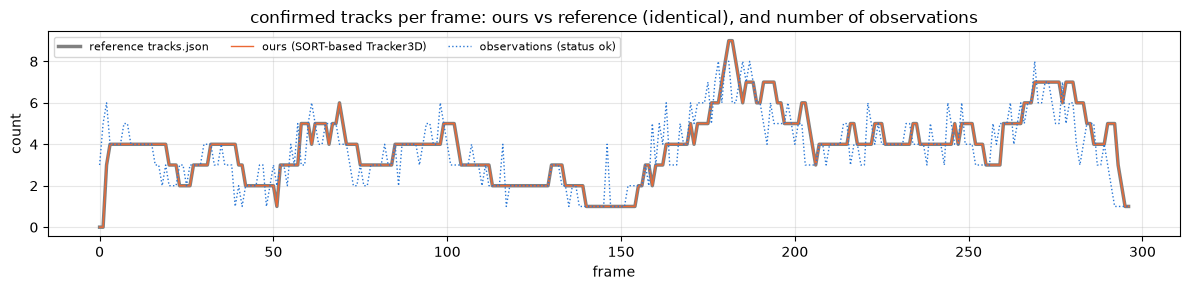

In [17]:
def run_tracking(objects_by_frame, cfg):
    """{frame_id: [Object3D]} → {frame_id: [트랙 dict(confirmed 만)]}, 그리고 프레임별 전체 트랙 기록(log)."""
    Track3D.count = 0                                 # id 는 0 부터 (출력은 +1) — 실행마다 초기화
    tracker = Tracker3D(cfg)
    out = {}
    for fid in sorted(objects_by_frame):              # 프레임 순서대로 매 프레임 호출 (건너뛰면 dt 가정이 깨진다)
        obs = [o for o in objects_by_frame[fid] if o.status == "ok" and o.center is not None]
        out[fid] = tracker.update(obs, fid)
    return out, tracker.log

tracks_mine, log = run_tracking(objects, cfg)

# tracks.json 과 비교
n_frames_same = sum(1 for f in tracks_ref if [r["track_id"] for r in tracks_mine[f]] == [r["track_id"] for r in tracks_ref[f]])
max_c = max((np.abs(np.array(a["center"]) - np.array(b["center"])).max() for f in tracks_ref for a, b in zip(tracks_mine[f], tracks_ref[f])), default=0.0)
same_flags = all(a["misses"] == b["misses"] and a["hits"] == b["hits"] and a["confirmed"] == b["confirmed"] for f in tracks_ref for a, b in zip(tracks_mine[f], tracks_ref[f]))
ids_mine = sorted({r["track_id"] for v in tracks_mine.values() for r in v}); ids_ref = sorted({r["track_id"] for v in tracks_ref.values() for r in v})
print(f"프레임별 confirmed id 목록 일치: {n_frames_same}/{len(tracks_ref)} 프레임, 중심 최대 차이 {max_c:.2e} m, hits/misses/confirmed 일치 {same_flags}")
print(f"confirmed 트랙 id 수: 우리 {len(ids_mine)}, 정답지 {len(ids_ref)} (같은 집합: {ids_mine == ids_ref}); 생성된 id 수(tentative 포함) {Track3D.count}")
assert n_frames_same == len(tracks_ref) and max_c < 1e-6

fig, ax = plt.subplots(figsize=(12, 3))
fr = sorted(tracks_ref)
ax.plot(fr, [len(tracks_ref[f]) for f in fr], "-", color="0.5", lw=2.5, label="reference tracks.json")
ax.plot(fr, [len(tracks_mine[f]) for f in fr], "-", color="#eb6834", lw=1, label="ours (SORT-based Tracker3D)")
ax.plot(fr, [len(obs_of(f)) for f in fr], ":", color="#2a78d6", lw=1, label="observations (status ok)")
ax.set_xlabel("frame"); ax.set_ylabel("count"); ax.legend(fontsize=8, ncol=3); ax.grid(alpha=0.3)
ax.set_title("confirmed tracks per frame: ours vs reference (identical), and number of observations"); fig.tight_layout(); plt.show()

BEV 궤적(프레임 0~60). GT 는 정답지 파서 `gt_boxes_by_frame` 로 읽는다 (XML 파서는 08 노트북에서 직접 만든다; 여기서는 비교용으로 빌려 쓴다).
GT 필터는 Phase 8 과 같은 근사: 카메라 수평 FOV 81.4° 안 (x > 0, |y| < x·tan 40.7°), x ≤ 70 m.

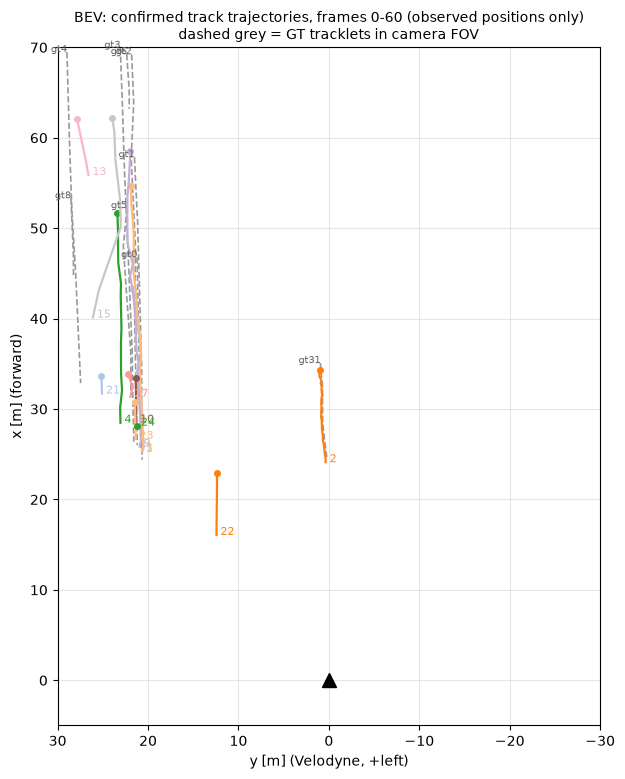

프레임 0~60: confirmed 트랙 13개, GT(FOV 안) 9개


In [18]:
from perceptrack3d.evaluation.tracklets import gt_boxes_by_frame   # 검증·비교용 (08 에서 직접 포팅)
import pandas as pd
gts = gt_boxes_by_frame(GT_XML)
tan_half = np.tan(np.radians(81.4) / 2)
def gt_in_view(f):
    return [b for b in gts.get(f, []) if b.center[0] > 0 and abs(b.center[1]) < b.center[0] * tan_half and b.center[0] <= cfg["fusion"]["roi"]["x_max"]]

log_df = pd.DataFrame(log)
F0, F1 = 0, 60
fig, ax = plt.subplots(figsize=(7, 9))
gt_traj = collections.defaultdict(list)
for f in range(F0, F1 + 1):
    for b in gt_in_view(f):
        gt_traj[b.tracklet_id].append(b.center[:2])
for gid, tr in gt_traj.items():
    tr = np.array(tr); ax.plot(tr[:, 1], tr[:, 0], "--", color="0.6", lw=1.2); ax.text(tr[0, 1], tr[0, 0], f"gt{gid}", color="0.4", fontsize=7, ha="right")
cmap = plt.get_cmap("tab20")
sub = log_df[(log_df.frame.between(F0, F1)) & log_df.confirmed & (log_df.misses == 0)]
for tid, g in sub.groupby("track_id"):
    g = g.sort_values("frame"); ax.plot(g.y, g.x, "-", color=cmap(tid % 20), lw=1.6); ax.plot(g.y.iloc[0], g.x.iloc[0], "o", color=cmap(tid % 20), ms=4)
    ax.text(g.y.iloc[-1], g.x.iloc[-1], f" {tid}", color=cmap(tid % 20), fontsize=8)
ax.plot(0, 0, "^", color="k", ms=10); ax.set_xlim(30, -30); ax.set_ylim(-5, 70); ax.set_aspect("equal"); ax.grid(alpha=0.3)
ax.set_xlabel("y [m] (Velodyne, +left)"); ax.set_ylabel("x [m] (forward)")
ax.set_title(f"BEV: confirmed track trajectories, frames {F0}-{F1} (observed positions only)\ndashed grey = GT tracklets in camera FOV", fontsize=10); plt.show()
print(f"프레임 {F0}~{F1}: confirmed 트랙 {sub.track_id.nunique()}개, GT(FOV 안) {len(gt_traj)}개")

**ID 스위치 사례 — gt3 (왼쪽 차선 원거리 주차 차량, tracklet 프레임 28~61, 평가 GT 로는 29~61)**. Phase 8 결과(`outputs/phase8/results.md` §4) 에서 gt3 은 트랙 15 → 23 → 24 → 23 으로 IDSW 3회다. 우리 추적기는 정답지와 결과가 같으므로 같은 현상이 나와야 한다. 원인을 융합 결과(status) 와 트랙 기록으로 확인한다.

gt3: 프레임 28~61, 거리 75 → 33 m
2 m 안에 들어온 트랙(tentative 포함):
track_id
15    프레임 32~44 (13프레임, confirmed 프레임 11)
21      프레임 49~51 (3프레임, confirmed 프레임 0)
23      프레임 54~61 (8프레임, confirmed 프레임 5)
24      프레임 57~58 (2프레임, confirmed 프레임 1)

프레임별 gt3 근처(3 m) 융합 객체의 status[점 수] — 관측이 깜빡이는 구간:
  f44: gt=(47.6,22.2)  sparse(3<5_points)[3pt], empty(no_points_after_filters)[0pt] 트랙 [(15, 'coast')]
  f45: gt=(46.2,22.2)  invalid(no_cluster)[9pt], sparse(1<5_points)[1pt]       트랙 []
  f46: gt=(44.8,22.1)  empty(no_points_after_filters)[0pt]                     트랙 []
  f47: gt=(43.5,22.0)  invalid(no_cluster)[16pt], empty(no_points_after_filters)[0pt] 트랙 []
  f48: gt=(42.1,22.0)  invalid(no_cluster)[5pt], empty(no_points_after_filters)[0pt] 트랙 []
  f49: gt=(40.6,21.9)  ok[10pt], invalid(no_cluster)[7pt], empty(no_points_after_filters)[0pt] 트랙 [(21, 'obs')]
  f50: gt=(39.2,21.9)  ok[15pt], empty(no_points_after_filters)[0pt]           트랙 [(21, 'obs')]
  f51: gt=(37.9,21.8)  empty(no_points_after_filt

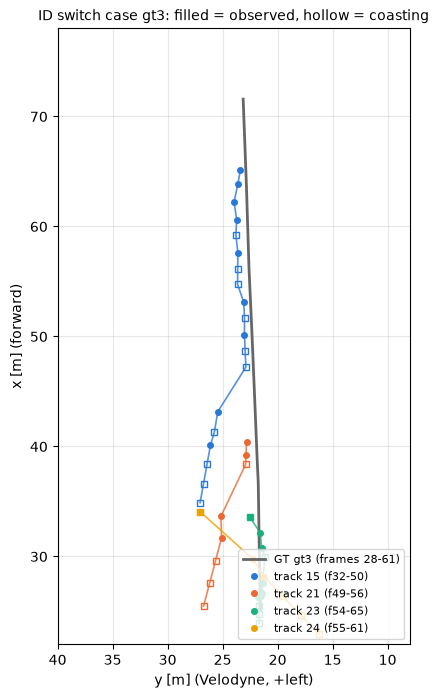

In [19]:
GT_ID = 3
gt3 = {f: b for f in range(0, 62) for b in gts.get(f, []) if b.tracklet_id == GT_ID}
near = log_df[[ (r.frame in gt3) and np.hypot(r.x - gt3[r.frame].center[0], r.y - gt3[r.frame].center[1]) < 2.0 for r in log_df.itertuples()]]
print(f"gt{GT_ID}: 프레임 {min(gt3)}~{max(gt3)}, 거리 {np.hypot(*gt3[min(gt3)].center[:2]):.0f} → {np.hypot(*gt3[max(gt3)].center[:2]):.0f} m")
print("2 m 안에 들어온 트랙(tentative 포함):")
print(near.groupby("track_id").frame.apply(lambda s: f"프레임 {s.min()}~{s.max()} ({len(s)}프레임, confirmed 프레임 {int(near[near.track_id == s.name].confirmed.sum())})").to_string())

print("\n프레임별 gt3 근처(3 m) 융합 객체의 status[점 수] — 관측이 깜빡이는 구간:")
for f in range(44, 62):
    c = gt3[f].center
    cand = [o for o in objects[f] if o.center is not None and np.linalg.norm(o.center[:2] - c[:2]) < 3.0] + [o for o in objects[f] if o.center is None]
    row = ", ".join(f"{o.status}{'(' + o.reason + ')' if o.reason else ''}[{o.n_points}pt]" for o in cand) or "(검출 없음)"
    trk_here = near[near.frame == f]
    print(f"  f{f}: gt=({c[0]:.1f},{c[1]:.1f})  {row:<55s} 트랙 {[(int(t), 'coast' if m > 0 else 'obs') for t, m in zip(trk_here.track_id, trk_here.misses)]}")

fig, ax = plt.subplots(figsize=(6, 8))
traj = np.array([gt3[f].center for f in sorted(gt3)])
ax.plot(traj[:, 1], traj[:, 0], "-", color="0.4", lw=2, label=f"GT gt{GT_ID} (frames {min(gt3)}-{max(gt3)})")
palette = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
for k, (tid, g) in enumerate(near.groupby("track_id")):
    g = log_df[log_df.track_id == tid].sort_values("frame")
    ax.plot(g.y, g.x, "-", color=palette[k % 5], lw=1.2, alpha=0.8)
    ax.plot(g[g.misses == 0].y, g[g.misses == 0].x, "o", color=palette[k % 5], ms=4, label=f"track {tid} (f{g.frame.min()}-{g.frame.max()})")
    ax.plot(g[g.misses > 0].y, g[g.misses > 0].x, "s", mfc="none", color=palette[k % 5], ms=5)
ax.set_xlim(40, 8); ax.set_ylim(22, 78); ax.set_aspect("equal"); ax.grid(alpha=0.3)
ax.set_xlabel("y [m] (Velodyne, +left)"); ax.set_ylabel("x [m] (forward)"); ax.legend(fontsize=8, loc="lower right")
ax.set_title(f"ID switch case gt{GT_ID}: filled = observed, hollow = coasting", fontsize=10); plt.show()

**원인** (위 출력과 궤적): (1) 40 m 밖에서는 LiDAR 점이 5~15개뿐이라 융합이 `sparse` / `no_cluster` 로 자주 실패한다 → 관측이 깜빡인다. (2) 트랙 15 는 coasting 으로 버티다 4 프레임 연속 놓치면(`max_misses` = 3) 삭제된다. (3) 잠깐 돌아온 관측으로 생긴 트랙은 `min_hits` = 3 을 못 채우고 죽어 출력에 나오지 않는다. (4) 30 m 안으로 들어와 검출이 안정되면 새 id 로 확정되는데, 프레임 57 부터 같은 차에서 `ok` 객체가 **2개**(클러스터가 갈라져 1 m 넘게 떨어짐) 나와 트랙이 하나 더 생기고 둘이 GT 에 번갈아 붙는다 → IDSW.
즉 칼만 필터·할당의 문제가 아니라 (a) 원거리 관측 결손과 (b) 융합의 중복 객체가 원인이다. SORT 기본값 `max_age = 1` 이었다면 훨씬 더 자주 끊겼을 것이다.

### 여기서 배우는 것

- **상태 정의가 바뀌면 `F`, `H`, `P`, `Q`, `R` 다섯 개를 전부 다시 써야 한다.** SORT 의 `P *= 10`, `Q[4:,4:] *= 0.01` 같은 스케일링은 픽셀 단위 2D 박스용이라 m 단위 3D 에 그대로 두면 속도 불확실성이 터무니없이 작아진다. 단위(m, m/s) 와 dt(0.1 s) 를 명시한 σ 파라미터로 바꿔야 한다.
- **행/열 규약**: SORT 의 비용 행렬은 행 = 검출, 정답지는 행 = 트랙. `matched[:, 0]` 이 무엇인지 헷갈리면 트랙을 관측에 갱신하는 대신 관측을 트랙에 갱신하는 버그가 난다 — 검증 셀에서 전치해서 비교했다.
- **최대화 vs 최소화**: IoU 는 클수록 좋고 d² 는 작을수록 좋다. `linear_assignment(-iou_matrix)` 의 부호와 `iou < thr` / `d² > gate` 비교 방향을 모두 뒤집어야 한다.
- **inf 는 scipy 가 못 다룬다**: 한 행이 전부 inf 면 `ValueError: cost matrix is infeasible`. "유한 비용 합보다 큰 값" 으로 바꾸고 결과에서 버리는 것이 실무 관행이다.
- **라이브러리 수식과 문헌 수식이 다를 수 있다**: filterpy 는 Joseph 형 `(I−KH)P(I−KH)ᵀ + KRKᵀ`, 정답지는 `(I−KH)P`. 최적 이득에서는 같지만(검증: 1e-12 수준), 수치적으로는 Joseph 형이 안전하다.
- **생명주기 규칙의 미묘한 차이**가 결과를 바꾼다: SORT 의 "연속 hit_streak" 과 "이번 프레임 관측된 것만 반환" 을 그대로 두면 정답지와 트랙 수가 달라진다(coasting 트랙이 빠짐). 대응표를 만들어 하나씩 맞췄다.
- **GPL 코드**를 가져올 때는 라이선스 표기를 남기고, 배포 시 전체 프로젝트 라이선스에 영향을 준다는 것을 기억한다. 학습 노트북에서는 원문 발췌에 저작권·라이선스 줄을 붙였다.

### 자가 점검 3문제

1. SORT 의 `self.kf.P[4:,4:] *= 1000.` 은 우리 `Track3D` 의 어느 줄에 해당하며, 왜 2D 픽셀 박스에서는 1000 이 "충분히 큰" 값이지만 3D m 단위에서는 `initial_vel_std` 를 따로 정해야 하는가?
2. 프레임 1 의 d² 행렬에서 유클리드로 3 m 떨어진 쌍의 d² 가 1 도 안 되는 이유는? (힌트: 예측 후 S 의 대각 값과 `initial_vel_std`)
3. SORT 의 반환 조건을 그대로 두면(`time_since_update < 1`) `tracks.json` 과 프레임당 트랙 수가 어느 방향으로 달라지고, Phase 8 의 정밀도·재현율은 각각 어떻게 움직이겠는가?

<details>
<summary>답</summary>

1. `self.kf.P = np.diag([r_std**2]*3 + [v0_std**2]*3)` 의 뒤 3개. 2D 박스는 픽셀 단위라 속도 분산 1000 px² (σ ≈ 32 px/프레임) 이 관측 잡음보다 충분히 크지만, m 단위에서 1000 m²/s² (σ ≈ 32 m/s) 는 마주 오는 차(25 m/s)도 덮는 값이라 우연히 비슷할 뿐이다. 단위와 dt 가 다르면 "충분히 큰" 기준이 달라지므로 물리 단위(σ_v = 10 m/s) 로 정한다.
2. 첫 예측에서 P⁻ 의 위치 분산은 R + dt²·σ_v0² + σ_p² = 0.25 + 1.0 + 0.25 = 1.5 m² 이고 S = P⁻₍₀₀₎ + R ≈ 1.75 m² 이므로 3 m 오차의 d² ≈ 9/1.75 ≈ 5 — 여전히 게이트(9.21) 안이다. 속도를 모르는 첫 프레임에 게이트가 넓은 것은 의도된 동작이다.
3. coasting 트랙(misses > 0)이 빠져 프레임당 트랙 수가 줄어든다(297 프레임에서 225개 예측 감소). Phase 8 표의 "coasting 제외" 행처럼 정밀도는 오르고(0.78 → 0.91), 재현율은 내린다(0.65 → 0.61).

</details>